In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn

import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
reset_random_seeds()    

df_train = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/train.csv")
df_test = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/test.csv")

split = len(df_train)

df = pd.concat([df_train,df_test])
input_col = 'text'
output_col = "label-fine"


X = df[input_col].values
Y = df[output_col].values

In [2]:
from custom_tokenizer import BytePairEncodingTokenizer
import re
import spacy
from tqdm.auto import tqdm


# load tokenizer
tokenizer = BytePairEncodingTokenizer()
tokenizer.load_tokenizer('tokenizer.pkl')


nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

HEX = re.compile(r'&#x[0-9A-Fa-f]+;')
DEC = re.compile(r'&#\d+;')
ASCII = re.compile(r'[^\x00-\x7F]+')
URL = re.compile(r'http\S+|www\S+')
ESCAPES = re.compile(r'[\n\t\r]+')

def clean_regex_only(text):
    """Only performs the fast regex string replacement."""
    x = str(text).lower()
    x = x.replace("&amp;","&").replace("<br />",'')
    x = HEX.sub('', x)
    x = DEC.sub("'", x)
    x = ASCII.sub("'", x)
    x = ESCAPES.sub(" ",x)
    x = URL.sub('LINK', x) 
    return x.strip()

def preprocess(text,nlp):
    clean_text = clean_regex_only(text)    
    sent = nlp.tokenizer(clean_text)
    sent = ' '.join([tok.text for tok in sent])
    return sent


X = [preprocess(sent,nlp) for sent in tqdm(X)]


  0%|          | 0/5952 [00:00<?, ?it/s]

In [3]:
tokenizer.maxlen = 256

X = [tokenizer.tokenize(x) for x in tqdm(X)]
X = np.array([tokenizer.add_padding(x) for x in tqdm(X)],np.int16)

  0%|          | 0/5952 [00:00<?, ?it/s]

  0%|          | 0/5952 [00:00<?, ?it/s]

In [4]:
xtrain,xtest = X[:split],X[split:]
ytrain,ytest = Y[:split],Y[split:]

In [5]:
MAXLEN = tokenizer.maxlen
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 4
FF_UNITS = D_MODEL * 3
PEAK_LR = 1e-4
END_LR = 1e-8
INIT_LR = 1e-8
WARMUP_RATE = 0.05
BATCH = 8
EMB_DIM = 128
VOCAB_SIZE = tokenizer.vocab_size

In [6]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask,sim_only=False,norm_only=False):
        
        if norm_only:
            score = torch.norm(x,dim=-1)

        elif sim_only:
            mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
            mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
            mean_vec = mean_vec[:,torch.newaxis,:]
            score = torch.cosine_similarity(mean_vec,x,dim=-1)
            
        elif (not sim_only) and (not norm_only):
            mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
            mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
            mean_vec = mean_vec[:,torch.newaxis,:]
            mean_vec = mean_vec.transpose(1,2)
            score = torch.matmul(x,mean_vec).squeeze(-1)
            
        score = torch.where(mask,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        return torch.sum(x * score,dim=1)
            
            
        
        

In [7]:
class FactorizeEmbeddingLayer(nn.Module):

    def __init__(self,vocab_size,d_model,maxlen):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.maxlen = maxlen

        self.emb = nn.Embedding(self.vocab_size,self.d_model // 2)
        self.fact_layer = nn.Linear(self.d_model // 2, self.d_model)
        self.pos_encoding = nn.Parameter(self._positional_encoding(),requires_grad=False)

    def _positional_encoding(self):
        pos = np.zeros((self.maxlen, self.d_model), dtype=np.float32)
        for p in range(self.maxlen):
            for i in range(self.d_model):
                exponent = 2 * (i // 2) / self.d_model
                angle = p / (10000 ** exponent)

                if i % 2 == 0:
                    pos[p, i] = np.sin(angle)
                else:
                    pos[p, i] = np.cos(angle)
        return torch.tensor(pos,dtype=torch.float32)

    def forward(self,x):
        mask = x == 0
        x = self.fact_layer(self.emb(x)) + self.pos_encoding[:x.shape[1], :].unsqueeze(0)
        return x,mask

In [8]:
from encoder_decoder import EncoderLayer
from torchinfo import summary


class Classifier(nn.Module):

    def __init__(self,d_model,vocab_size,maxlen,n_heads,ff_units,n_layers,
                 n_classes=1,sim_only=False,norm_only=False):
        super().__init__()
        
        self.n_layers = n_layers
        self.sim_only = sim_only
        self.norm_only = norm_only
        
        
        self.emb = FactorizeEmbeddingLayer(vocab_size,d_model,maxlen)
        self.encoder = EncoderLayer(d_model,n_heads,ff_units)
        self.pooling = GeometricPooling()
        self.out = nn.Linear(d_model,n_classes)
        

    def forward(self,i,return_pool=False):

        x,mask = self.emb(i)

        for _ in range(self.n_layers):
            x = self.encoder([x,mask])

        x = self.pooling(x,mask=mask,norm_only=self.norm_only,sim_only=self.sim_only)
        
        if return_pool:
            return x
        
        x = self.out(x)

        return x


reset_random_seeds()

n_classes = len(np.unique(ytrain))

device = torch.device("cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS)

model = model.to(device)

inp = torch.randint(0,VOCAB_SIZE,(BATCH,MAXLEN))
print(summary(model,input_data=inp))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)




Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [8, 1]                    --
├─FactorizeEmbeddingLayer: 1-1           [8, 256, 256]             65,536
│    └─Embedding: 2-1                    [8, 256, 128]             2,565,248
│    └─Linear: 2-2                       [8, 256, 256]             33,024
├─EncoderLayer: 1-2                      [8, 256, 256]             --
│    └─MultiHeadAttention: 2-3           [8, 256, 256]             --
│    │    └─Linear: 3-1                  [8, 256, 256]             65,536
│    │    └─Linear: 3-2                  [8, 256, 256]             65,536
│    │    └─Linear: 3-3                  [8, 256, 256]             65,536
│    │    └─Dropout: 3-4                 [8, 8, 256, 256]          --
│    │    └─Linear: 3-5                  [8, 256, 256]             65,792
│    │    └─Dropout: 3-6                 [8, 256, 256]             --
│    └─LayerNorm: 2-4                    [8, 256, 256]

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(y_true, y_pred):
    
    is_standard_binary = len(set(y_true)) <= 2 and set(y_true).issubset({0, 1})
    avg = 'binary' if is_standard_binary else 'weighted'
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

metrics = {"sim_and_norm":None,"norm_only":None,"sim_only":None}



In [10]:
from torch.utils.data import TensorDataset, DataLoader
import torch_optimizer

def create_tensor_data(x,y,batch,shuffle=True):
    
    x_ = torch.tensor(x,dtype=torch.int32,device=device)
    y_ = torch.tensor(y,dtype=torch.int32,device=device)
    data = TensorDataset(x_,y_)
    data = DataLoader(data,batch_size=batch,shuffle=shuffle)
    return data

train = create_tensor_data(xtrain,ytrain,BATCH)
test = create_tensor_data(xtest,ytest,BATCH * 2,shuffle=False)

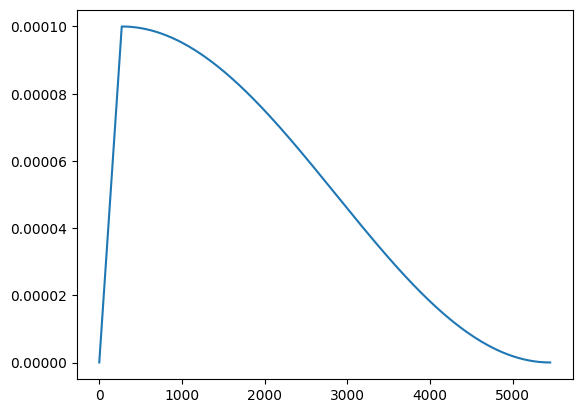

In [11]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

EPOCHS = 8
train_steps = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(train_steps,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,train_steps+1)])

In [12]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS=10,file='saved_weights.pt'):
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            x,y = batch
            y = y.long()
            pred = model(x)
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)

        print(f'Train Loss = {loss}')

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(test):

                x,y = batch
                y = y.long()
                pred = model(x)
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()

        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('-------------------------------------')
        print()

In [13]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes)
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='sim_and_norm.pt')

state_dict = torch.load('sim_and_norm.pt', map_location=device)
model.load_state_dict(state_dict)

1/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 2.4647
Val Loss = 1.7781
--weights saved
-------------------------------------

2/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 1.5279
Val Loss = 1.4008
--weights saved
-------------------------------------

3/8


...

  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5373
Val Loss = 1.0496
--weights saved
-------------------------------------

8/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5028
Val Loss = 1.045
--weights saved
-------------------------------------



<All keys matched successfully>

In [14]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds,zero_division=True))
print(f1_score(ytest,preds,average='macro'))  

metrics['sim_and_norm'] = get_metrics_dict(ytest,preds)


              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      1.00      0.00         0
           2       0.50      0.19      0.27        16
           3       1.00      0.75      0.86         8
           4       0.78      0.95      0.85        55
           5       0.67      0.67      0.67         6
           6       1.00      0.00      0.00         1
           7       0.80      0.96      0.87       123
           8       0.98      0.94      0.96        47
           9       1.00      1.00      1.00         6
          10       1.00      0.00      0.00         2
          11       0.62      0.71      0.67         7
          12       0.62      0.80      0.70        10
          13       0.80      0.89      0.84         9
          14       0.64      0.74      0.69        74
          17       0.33      0.25      0.29         4
          18       0.75      1.00      0.86         3
          19       0.90    

In [15]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes,sim_only=True)
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='sim_only.pt')

state_dict = torch.load('sim_only.pt', map_location=device)
model.load_state_dict(state_dict)

1/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 2.4609
Val Loss = 1.8021
--weights saved
-------------------------------------

2/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 1.5456
Val Loss = 1.4123
--weights saved
-------------------------------------

3/8


...

  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5805
Val Loss = 1.1066
--weights saved
-------------------------------------

8/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5458
Val Loss = 1.0992
--weights saved
-------------------------------------



<All keys matched successfully>

In [16]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds,zero_division=True))
print(f1_score(ytest,preds,average='macro'))  

metrics['sim_only'] = get_metrics_dict(ytest,preds)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      1.00      0.00         0
           2       0.33      0.12      0.18        16
           3       0.86      0.75      0.80         8
           4       0.79      0.96      0.87        55
           5       0.57      0.67      0.62         6
           6       1.00      0.00      0.00         1
           7       0.81      0.96      0.88       123
           8       0.98      0.96      0.97        47
           9       0.67      1.00      0.80         6
          10       1.00      0.00      0.00         2
          11       0.62      0.71      0.67         7
          12       0.50      0.60      0.55        10
          13       0.75      1.00      0.86         9
          14       0.63      0.77      0.70        74
          17       0.00      0.00      0.00         4
          18       1.00      1.00      1.00         3
          19       0.90    

In [17]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes,norm_only=True)
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='norm_only.pt')

state_dict = torch.load('norm_only.pt', map_location=device)
model.load_state_dict(state_dict)

1/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 2.4603
Val Loss = 1.8032
--weights saved
-------------------------------------

2/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 1.5462
Val Loss = 1.4133
--weights saved
-------------------------------------

3/8


...

  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.5816
Val Loss = 1.1085
--weights saved
-------------------------------------

8/8


  0%|          | 0/682 [00:00<?, ?it/s]

Train Loss = 0.547
Val Loss = 1.1013
--weights saved
-------------------------------------



<All keys matched successfully>

In [18]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds,zero_division=True))
print(f1_score(ytest,preds,average='macro'))  

metrics['norm_only'] = get_metrics_dict(ytest,preds)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      1.00      0.00         0
           2       0.33      0.12      0.18        16
           3       0.86      0.75      0.80         8
           4       0.79      0.96      0.87        55
           5       0.57      0.67      0.62         6
           6       1.00      0.00      0.00         1
           7       0.81      0.96      0.88       123
           8       0.98      0.96      0.97        47
           9       0.67      1.00      0.80         6
          10       1.00      0.00      0.00         2
          11       0.62      0.71      0.67         7
          12       0.50      0.60      0.55        10
          13       0.75      1.00      0.86         9
          14       0.63      0.77      0.70        74
          17       0.00      0.00      0.00         4
          18       1.00      1.00      1.00         3
          19       0.90    

In [19]:
import json


with open("ablation1_metrics_.json",'w') as f:
    json.dump(metrics,f)

In [20]:
metrics

{'sim_and_norm': {'accuracy': 0.748,
  'precision': 0.7209615690063277,
  'recall': 0.748,
  'f1': 0.7172755859180998},
 'norm_only': {'accuracy': 0.754,
  'precision': 0.7112301781072972,
  'recall': 0.754,
  'f1': 0.717427036631979},
 'sim_only': {'accuracy': 0.752,
  'precision': 0.7105635114406305,
  'recall': 0.752,
  'f1': 0.7150386308348775}}

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


def load_model(name,sim_only=False,norm_only=False):
    model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                       n_classes=n_classes,norm_only=norm_only,sim_only=sim_only)

    model = model.to('cuda')
    state_dict = torch.load(f'{name}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

reset_random_seeds()

model0 = load_model('sim_and_norm')
model1 = load_model('sim_only',sim_only=True)
model2 = load_model('norm_only',norm_only=True)

def get_pooled_vectors(model,test):
    
    with torch.no_grad():

        vectors = []

        for x,_ in test:
            x = x.to('cuda')
            pool_vec = model(x,return_pool=True)
            pool_vec = pool_vec.cpu().numpy()
            vectors.extend(pool_vec)
        
        vectors = np.array(vectors,dtype=np.float32)
        
        return vectors

reset_random_seeds()    

vectors0 = get_pooled_vectors(model0,test)
vectors1 = get_pooled_vectors(model1,test)
vectors2 = get_pooled_vectors(model2,test)


def cluster_eval(embeddings,true_labels,name='',classes=len(set(ytrain))):
    kmeans = KMeans(n_clusters=classes, n_init=10, random_state=42)
    cluster_preds = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(true_labels, cluster_preds)
    print(f"Clustering ARI against True Sentiment: {ari:.4f} ({name})")
    return ari,name

cluster_eval_metrics = {}

ari,name = cluster_eval(vectors0,ytest,'sim_and_norm')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors1,ytest,'sim_only')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors2,ytest,'norm_only')
cluster_eval_metrics[name] = ari

with open("ablation1_cluster_metrics_.json",'w') as f:
    json.dump(cluster_eval_metrics,f)

Clustering ARI against True Sentiment: 0.2941 (sim_and_norm)
Clustering ARI against True Sentiment: 0.2850 (sim_only)
Clustering ARI against True Sentiment: 0.2809 (norm_only)
